# **Program 1**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import read_csv as rd

In [3]:
df=rd('EDAibm_hr_employee-attrition.csv')

In [5]:
num=df.select_dtypes(include='number').columns
cat=df.select_dtypes(exclude='number').columns

In [10]:
n=input("Enter the number col")
if n in num:
    col=df[n]
    mean=col.mean()
    median=col.median()
    mode=col.mode()
    std=col.std()
    var=col.var()
    range=col.max()-col.min()
    q1=col.quantile(0.25)
    q3=col.quantile(0.75)
    iqr=q3-q1
    lb=q1-(1.5*iqr)
    ub=q3+(1.5*iqr)
    outliers=col[(col<lb)|(col>lb)]
    print(f"Mean: {mean}\nMedian: {median}\nMode: {mode}\nStandard Deviation: {std}\nVariance: {var}\nRange: {range}\n\nOutliers: {len(outliers)}")
else:
    print("Not a number column")

Mean: 36.923809523809524
Median: 36.0
Mode: 0    35
Name: Age, dtype: int64
Standard Deviation: 9.135373489136734
Variance: 83.45504878602227
Range: 42

Outliers: 1470


<Axes: xlabel='Age', ylabel='Count'>

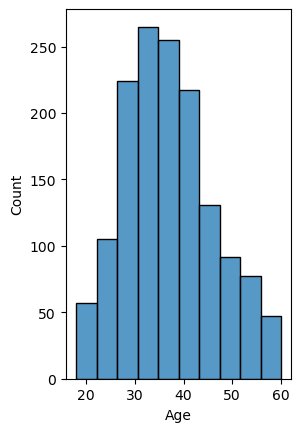

In [11]:
plt.subplot(1,2,1)
sns.histplot(col,bins=10)


<Axes: ylabel='Age'>

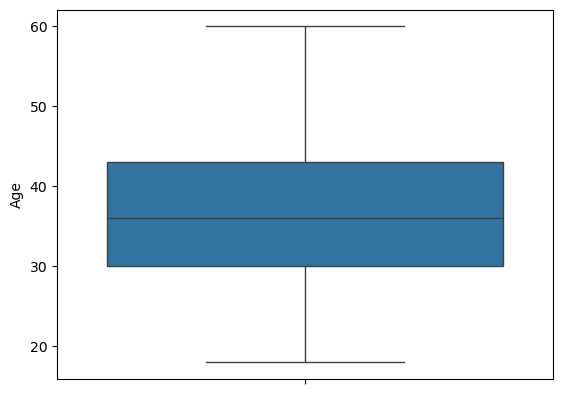

In [12]:
sns.boxplot(col)

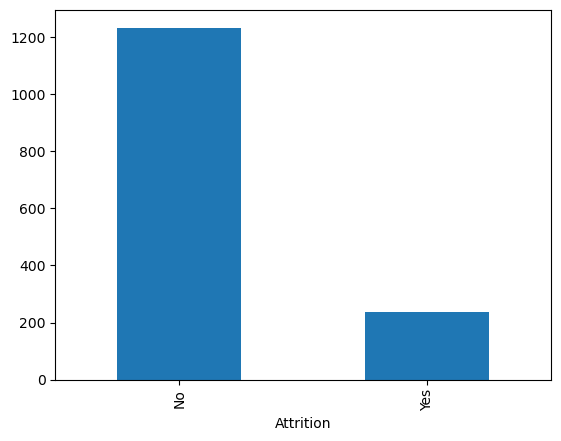

In [13]:
c=input("Enter the cat col")
if c in cat:
    col=df[c].value_counts()
    cho=input("Enter the type of plot bar for bar pie for pie")
    if cho.lower() == 'bar':
        col.plot(kind='bar')
    elif cho.lower() == 'pie':
        col.plot(kind='pie')
    else:
        print("Invalid choice")
else:
    print("Invalid column name") 

# **Program 2**

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [16]:
df=sns.load_dataset('iris')
x='petal_length'
y='sepall_length'

In [23]:
corr=df[['petal_length','sepal_length']].corr('pearson')
cov=df[['petal_length','sepal_length']].cov()
print(f'{cov} \n{corr}')

              petal_length  sepal_length
petal_length      3.116278      1.274315
sepal_length      1.274315      0.685694 
              petal_length  sepal_length
petal_length      1.000000      0.871754
sepal_length      0.871754      1.000000


In [24]:
d=df.iloc[:,:-1]
cov=d.cov()
corr=d.corr()

<Axes: >

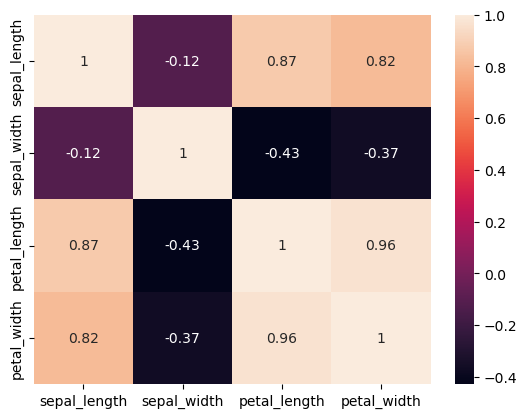

In [30]:
sns.heatmap(corr,annot=True)

# **Program 3**

In [33]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [34]:
iris=load_iris()
x=iris.data
y=iris.target

In [36]:
ss=StandardScaler()
td1=ss.fit_transform(x)

In [37]:
pc=PCA(n_components=2)
td2=pc.fit_transform(td1)

In [38]:
color=['red','greeen','blue']
pdf=pd.DataFrame(td2,columns=['PC1','PC2'])
pdf['Species']=y

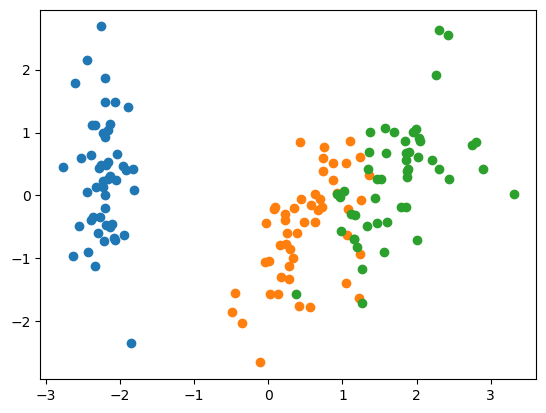

In [39]:
for i, color in zip([0,1,2],color):
    plt.scatter(
        pdf[pdf['Species']==i]['PC1'],
        pdf[pdf['Species']==i]['PC2']
    )
plt.plot()
plt.show()

# **Program 4**

In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split as tts
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score as ass, f1_score as f1
from sklearn.datasets import load_iris

In [45]:
iris=load_iris()
x=iris.data; y=iris.target
k_val=[1,3,5]


In [46]:
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=43)

In [56]:
def nei (x_train,x_test,y_train,y_test,k_val,weighted=False):
    results={}
    for k in k_val:
        if weighted:
            knn=KNeighborsClassifier(n_neighbors=k,weights='distance')
        else:
            knn=KNeighborsClassifier(n_neighbors=k,weights='uniform')
        knn.fit(x_train,y_train)
        y_pred=knn.predict(x_test)
        acc=ass(y_test,y_pred)
        f11=f1(y_test,y_pred,average='weighted')
        results[k]={
            'acc':acc,
            'f1':f11
        }
    return results

In [57]:
wk=nei(x_train,x_test,y_train,y_test,k_val,weighted=True)
for k,m in wk.items():
    print(f"{k}, {m['acc']}, {m['f1']}") 

1, 1.0, 1.0
3, 1.0, 1.0
5, 1.0, 1.0


In [59]:
nwk=nei(x_train,x_test,y_train,y_test,k_val,weighted=False)
for i,m in nwk.items():
    print(f"{i}, {m['acc']}, {m['f1']}")

1, 1.0, 1.0
3, 1.0, 1.0
5, 1.0, 1.0


In [60]:
for k in k_val:
    wa= wk[k]['acc']
    na=nwk[k]['acc']
    print(f"{k}, {wa}, {na}")

1, 1.0, 1.0
3, 1.0, 1.0
5, 1.0, 1.0
